In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import glob
import re

from supporting_code import logits_to_affirm_logit


def load_experiment_results(path):
    model_slug = re.match(r"^(.*/)?elicit-beliefs-(.*)\.pt$", path).group(2)
    data = torch.load(path, weights_only=False)
    logits = data["logits"]
    top_other_logit = data["top_other_logit"]
    top_other_id = data["top_other_id"]
    top_other_token = data["top_other_token"]
    return model_slug, logits, top_other_logit, top_other_id, top_other_token


def compute_metrics(p_affirm_logit, logits, top_other_logit):
    from scipy.special import expit
    
    p_affirm_logit = np.asarray(p_affirm_logit)
    mean_p_affirm = expit(p_affirm_logit).mean(axis=1)
    certainty = np.vstack((mean_p_affirm, 1 - mean_p_affirm)).max(axis=0)

    stability = -p_affirm_logit.std(axis=1)

    # TODO: Leakage is computed is the sum of all other tokens, excluding
    # Yes, No, True, False, which isn't quite right since we should use either
    # (Yes, No) or (True, False) as viable tokens and not all 4 of them. That
    # depends on which prompt template was used though so, for now, this
    # calculation is good enough.
    all_logits = torch.hstack((logits, top_other_logit[:, None]))
    all_probs = all_logits.softmax(axis=1)
    leakage = np.array(all_probs[:, 4:].sum(axis=1))

    from scipy.stats import spearmanr
    corr = spearmanr(p_affirm_logit).statistic
    if np.any(np.isnan(corr)):
        correig = np.nan
    else:
        correig = np.linalg.eig(corr)[0][0] / p_affirm_logit.shape[1]

    aggregate_function = np.mean
    return {
        'certainty': aggregate_function(certainty),
        'stability': aggregate_function(stability),
        'correig': correig,
        'leakage': aggregate_function(leakage),
    }

all_metrics = {}
for path in glob.glob("results/*.pt"):
    model_slug, logits, top_other_logit, top_other_id, top_other_token = load_experiment_results(path)
    p_affirm_logit = logits_to_affirm_logit(logits)
    all_metrics[model_slug] = compute_metrics(p_affirm_logit, logits, top_other_logit)

print(f"Loaded results for {len(all_metrics)} models.")

/var/folders/h2/n9tkny1d1wl46ndfc_hgtt_40000gn/T/ipykernel_90450/1054601881.py:36: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  leakage = np.array(all_probs[:, 4:].sum(axis=1))
/var/folders/h2/n9tkny1d1wl46ndfc_hgtt_40000gn/T/ipykernel_90450/1054601881.py:36: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  leakage = np.array(all_probs[:, 4:].sum(axis=1))


Loaded results for 53 models.


In [2]:
model_sizes = {
    "meta-llama/Llama-3.2-1B-Instruct": 1235814400,
    "meta-llama/Llama-3.2-3B-Instruct": 3212749824,
    "Qwen/Qwen3.5-0.8B": 873438784,
    "Qwen/Qwen3.5-2B": 2274069824,
    "Qwen/Qwen3.5-4B": 4659865088,
    "Qwen/Qwen3-4B-Instruct-2507": 4022468096,
    "Qwen/Qwen3-0.6B": 751632384,
    "Qwen/Qwen3-1.7B": 2031739904,
    "Qwen/Qwen3-4B": 4022468096,
    "Qwen/Qwen2.5-0.5B-Instruct": 494032768,
    "Qwen/Qwen2.5-1.5B-Instruct": 1543714304,
    "Qwen/Qwen2.5-3B-Instruct": 3085938688,
    "google/gemma-3-270m-it": 268098176,
    "google/gemma-3-1b-it": 999885952,
    "google/gemma-3-4b-it": 4300079472,
    "google/gemma-2-2b-it": 2614341888,
    "microsoft/Phi-4-mini-flash-reasoning": 3852562944,
    "microsoft/Phi-4-mini-reasoning": 3836021760,
    "microsoft/Phi-4-mini-instruct": 3836021760,
    "microsoft/Phi-3.5-mini-instruct": 3821079552,
    "microsoft/Phi-3-mini-128k-instruct": 3821079552,
    "allenai/OLMo-2-0425-1B-Instruct": 1484916736,
    "google/gemma-4-E2B-it": 5123178051,
    "allenai/Olmo-3-7B-Instruct": 7298617344,  # This is wrong on HuggingFace: 528384 = 528k which is far too small. Using the value from OLMo-2-1124-7B-Instruct instead.
    "allenai/OLMo-2-1124-7B-Instruct": 7298617344,
    "microsoft/Phi-3-small-128k-instruct": 7392272384,
    "Qwen/Qwen2.5-7B-Instruct": 7615616512,
    "meta-llama/Llama-3.1-8B-Instruct": 8030261248,
    "meta-llama/Meta-Llama-3-8B-Instruct": 8030261248,
    "Qwen/Qwen3-8B": 8190735360,
    "google/gemma-4-E4B-it": 7996156490,
    "google/gemma-2-9b-it": 9241705984,
    "Qwen/Qwen3.5-9B": 9653104368,
    "google/gemma-4-12B-it": 11959730224,
    "google/gemma-3-12b-it": 12187325040,
    "microsoft/Phi-3-medium-128k-instruct": 13960238080,
    "allenai/OLMo-2-1124-13B-Instruct": 13716198400,
    "Qwen/Qwen3-14B": 14768307200,
    "Qwen/Qwen2.5-14B-Instruct": 14770033664,
    "microsoft/Phi-4-reasoning": 14659507200,
    "microsoft/Phi-4-reasoning-plus": 14659507200,
    "microsoft/phi-4": 14659507200,
    "google/gemma-4-26B-A4B-it": 26544131376,
    "google/gemma-3-27b-it": 27432406640,
    "google/gemma-2-27b-it": 27227128320,
    "Qwen/Qwen3.6-27B": 27781427952,
    "Qwen/Qwen3.5-27B": 27781427952,
    "Qwen/Qwen3-30B-A3B-Instruct-2507": 30532122624,
    "Qwen/Qwen3-30B-A3B": 30532122624,
    "allenai/Olmo-3.1-32B-Instruct": 32233522176,
    "allenai/OLMo-2-0325-32B-Instruct": 32234279936,
    "google/gemma-4-31B-it": 32682372656,
    "Qwen/Qwen2.5-32B-Instruct": 32763876352,
    "Qwen/Qwen3-32B": 32762123264,
    "Qwen/Qwen3.6-35B-A3B": 35951822704,
    "Qwen/Qwen3.5-35B-A3B": 35951822704,
    "microsoft/Phi-3.5-MoE-instruct": 41873153344,
    "meta-llama/Llama-3.3-70B-Instruct": 70553706496,
    "meta-llama/Llama-3.1-70B-Instruct": 70553706496,
    "meta-llama/Meta-Llama-3-70B-Instruct": 70553706496,
    "Qwen/Qwen2.5-72B-Instruct": 72706203648,
    "meta-llama/Llama-4-Scout-17B-16E-Instruct": 108641793536,
    "Qwen/Qwen3.5-122B-A10B": 125086497008,
}

# Map slug to HuggingFace URL
model_urls = {
    key.split('/')[-1]: "https://huggingface.co/" + key
    for key in model_sizes.keys()}

# Map slug to total parameter count
model_sizes = {
    key.split('/')[-1]: value
    for key, value in model_sizes.items()}

# Add model size to model metrics
for model_slug, metrics in all_metrics.items():
    metrics['size'] = model_sizes[model_slug]

In [3]:
pattern = re.compile(r'[a-zA-Z]+')  # Used to extract model family from model slug

plot_size = []
plot_certainty = []
plot_stability = []
plot_correig = []
plot_leakage = []
plot_labels = []
plot_slug = []
for model_slug, metrics in all_metrics.items():
    if metrics['leakage'] < 0.99:  # Only use results where models were willing to answer yes/no
        plot_slug.append(model_slug)
        plot_size.append(metrics['size'])
        plot_certainty.append(metrics['certainty'])
        plot_stability.append(metrics['stability'])
        plot_correig.append(metrics['correig'])
        plot_leakage.append(metrics['leakage'])
        plot_labels.append(pattern.match(model_slug).group().lower().replace('meta', 'llama'))

In [4]:
# Assign plot markers to model families
unique = sorted(set(plot_labels))
markers = ['o', 's', 'P', 'X', 'v', '^', '<', '>']
marker_map = {
    slug: markers[unique.index(slug)]
    for slug in unique}
print(f"Plotting results for {len(plot_size)} models from {len(unique)} model families")

Plotting results for 34 models from 5 model families


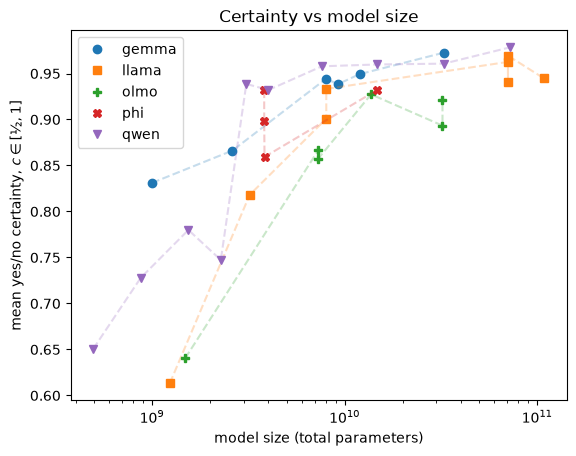

In [5]:
plt.figure()
plt.title('Certainty vs model size')
for label_index, label in enumerate(unique):
    x = np.array([plot_size[i] for i in range(len(plot_labels)) if plot_labels[i] == label])
    y = np.array([plot_certainty[i] for i in range(len(plot_labels)) if plot_labels[i] == label])
    i = np.argsort(x)
    marker = marker_map[label]
    plt.semilogx(x[i], y[i], marker=marker, label=label, linestyle='none', color=f'C{label_index}')
    plt.semilogx(x[i], y[i], marker='none', linestyle='--', alpha=0.25, color=f'C{label_index}')
plt.legend()
plt.xlabel(r'model size (total parameters)')
plt.ylabel(r'mean yes/no certainty, $c \in [½,1]$')
plt.show()

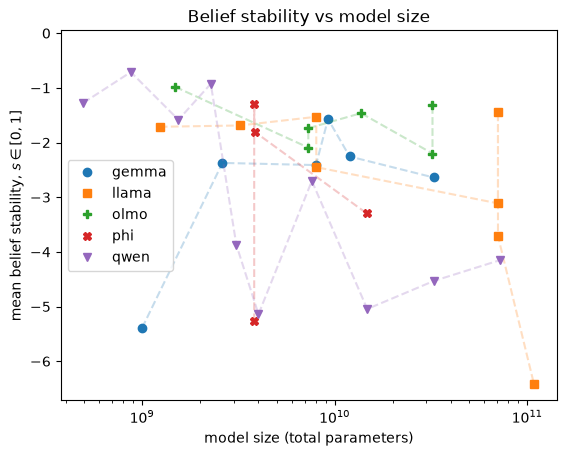

In [6]:
plt.figure()
plt.title('Belief stability vs model size')
for label_index, label in enumerate(unique):
    x = np.array([plot_size[i] for i in range(len(plot_labels)) if plot_labels[i] == label])
    y = np.array([plot_stability[i] for i in range(len(plot_labels)) if plot_labels[i] == label])
    i = np.argsort(x)
    marker = marker_map[label]
    plt.semilogx(x[i], y[i], marker=marker, label=label, linestyle='none', color=f'C{label_index}')
    plt.semilogx(x[i], y[i], marker='none', linestyle='--', alpha=0.25, color=f'C{label_index}')
plt.legend()
plt.ylim(plt.ylim()[0], 0.05)
plt.xlabel(r'model size (total parameters)')
plt.ylabel(r'mean belief stability, $s \in [0,1]$')
plt.show()

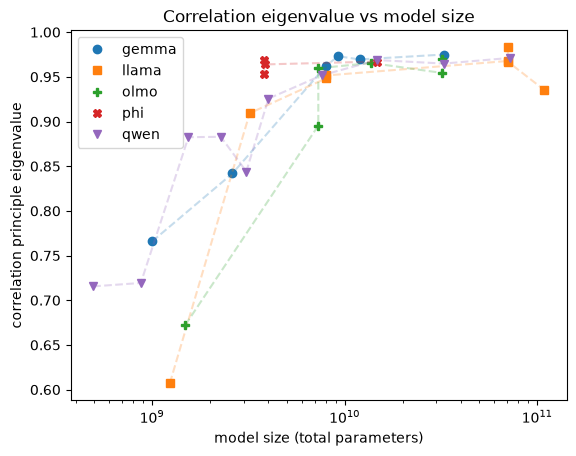

In [7]:
plt.figure()
plt.title('Correlation eigenvalue vs model size')
for label_index, label in enumerate(unique):
    x = np.array([plot_size[i] for i in range(len(plot_labels)) if plot_labels[i] == label])
    y = np.array([plot_correig[i] for i in range(len(plot_labels)) if plot_labels[i] == label])
    i = np.argsort(x)
    marker = marker_map[label]
    plt.semilogx(x[i], y[i], marker=marker, label=label, linestyle='none', color=f'C{label_index}')
    plt.semilogx(x[i], y[i], marker='none', linestyle='--', alpha=0.25, color=f'C{label_index}')
plt.legend()
plt.xlabel(r'model size (total parameters)')
plt.ylabel(r'correlation principle eigenvalue')
plt.show()

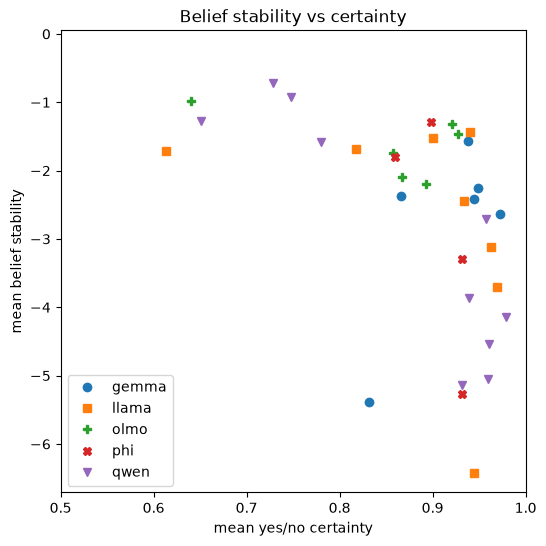

In [8]:
plt.figure(figsize=(6, 6))
plt.title('Belief stability vs certainty')
for label_index, label in enumerate(unique):
    x = np.array([plot_certainty[i] for i in range(len(plot_labels)) if plot_labels[i] == label])
    y = np.array([plot_stability[i] for i in range(len(plot_labels)) if plot_labels[i] == label])
    i = np.argsort(x)
    marker = marker_map[label]
    plt.plot(x[i], y[i], marker=marker, label=label, linestyle='none', color=f'C{label_index}')
    plt.plot(x[i], y[i], marker='none', linestyle='none', alpha=0.25, color=f'C{label_index}')
plt.legend(loc='lower left')
plt.ylim(plt.ylim()[0], 0.05)
plt.xlim(0.5, 1)
plt.xlabel(r'mean yes/no certainty')
plt.ylabel(r'mean belief stability')
plt.show()

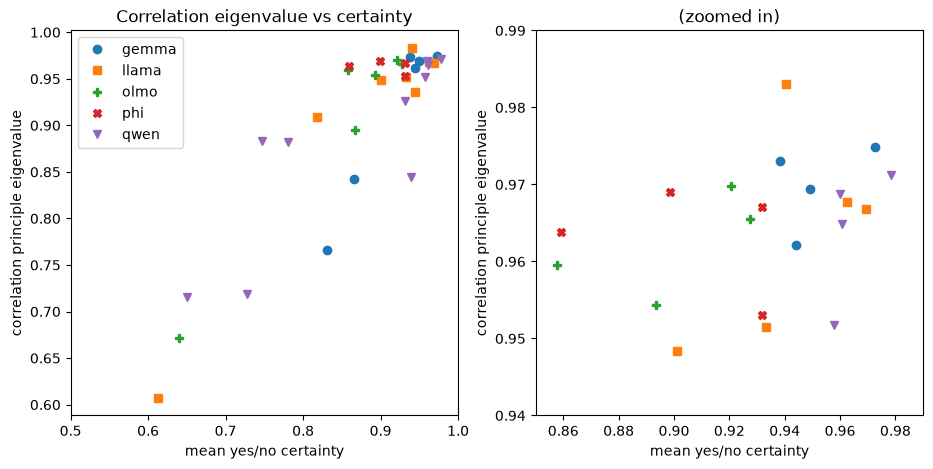

In [9]:
plt.figure(figsize=(11, 5))
for plot_i in range(2):
    plt.subplot(1, 2, plot_i + 1)
    for label_index, label in enumerate(unique):
        x = np.array([plot_certainty[i] for i in range(len(plot_labels)) if plot_labels[i] == label])
        y = np.array([plot_correig[i] for i in range(len(plot_labels)) if plot_labels[i] == label])
        i = np.argsort(x)
        marker = marker_map[label]
        plt.plot(x[i], y[i], marker=marker, label=label, linestyle='none', color=f'C{label_index}')
        plt.plot(x[i], y[i], marker='none', linestyle='none', alpha=0.25, color=f'C{label_index}')
    if plot_i == 0:
        plt.title('Correlation eigenvalue vs certainty')
        plt.legend(loc='upper left')
        plt.xlim(0.5, 1)
    else:
        plt.title('(zoomed in)')
        plt.xlim(0.85, 0.99)
        plt.ylim(0.94, 0.99)
    plt.xlabel(r'mean yes/no certainty')
    plt.ylabel(r'correlation principle eigenvalue')
plt.show()

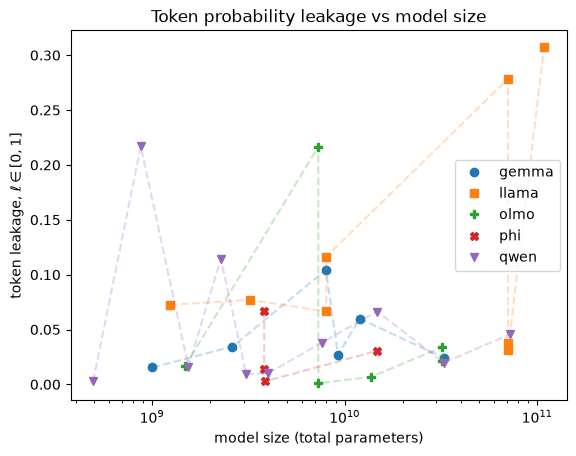

In [10]:
plt.figure()
plt.title('Token probability leakage vs model size')
for label_index, label in enumerate(unique):
    x = np.array([plot_size[i] for i in range(len(plot_labels)) if plot_labels[i] == label])
    y = np.array([plot_leakage[i] for i in range(len(plot_labels)) if plot_labels[i] == label])
    i = np.argsort(x)
    marker = marker_map[label]
    plt.semilogx(x[i], y[i], marker=marker, label=label, linestyle='none', color=f'C{label_index}')
    plt.semilogx(x[i], y[i], marker='none', linestyle='--', alpha=0.25, color=f'C{label_index}')
plt.legend()
plt.xlabel(r'model size (total parameters)')
plt.ylabel(r'token leakage, $\ell \in [0,1]$')
plt.show()

In [11]:
print("| Model | Size | **Corr eig in [0,1]** | Certainty in [0.5, 1] | Leakage in [0,1] |")
print("|-------|:----:|:---------------------:|:---------------------:|:----------------:|")
for model_slug, metrics in sorted(filter(lambda item: not np.isnan(item[1]['correig']), all_metrics.items()), key=lambda item: item[1]['correig'], reverse=True):
    if model_slug in plot_slug:
        printed_slug = model_slug.replace('-', ' ').title().replace('Meta Llama', 'Llama')
        print(f"| {'[' + printed_slug + '](' + model_urls[model_slug] + ')':100} | {metrics['size']/1e9:5.1f}B | {metrics['correig']:.2f} | {metrics['certainty']:.2f} | {metrics['leakage']:.3f} | ")

| Model | Size | **Corr eig in [0,1]** | Certainty in [0.5, 1] | Leakage in [0,1] |
|-------|:----:|:---------------------:|:---------------------:|:----------------:|
| [Llama 3.1 70B Instruct](https://huggingface.co/meta-llama/Llama-3.1-70B-Instruct)                   |  70.6B | 0.98 | 0.94 | 0.037 | 
| [Gemma 4 31B It](https://huggingface.co/google/gemma-4-31B-it)                                       |  32.7B | 0.97 | 0.97 | 0.024 | 
| [Gemma 2 9B It](https://huggingface.co/google/gemma-2-9b-it)                                         |   9.2B | 0.97 | 0.94 | 0.027 | 
| [Qwen2.5 72B Instruct](https://huggingface.co/Qwen/Qwen2.5-72B-Instruct)                             |  72.7B | 0.97 | 0.98 | 0.046 | 
| [Olmo 2 0325 32B Instruct](https://huggingface.co/allenai/OLMo-2-0325-32B-Instruct)                  |  32.2B | 0.97 | 0.92 | 0.021 | 
| [Gemma 4 12B It](https://huggingface.co/google/gemma-4-12B-it)                                       |  12.0B | 0.97 | 0.95 | 0.060 | 
| [Phi 3 M